Path setup

In [1]:
import sys
sys.path.append("..")

Imports

In [2]:
from src.similarity.batch_comparator import compare_students_to_master
from src.similarity.vectorizer import TfidfSimilarityVectorizer
from src.preprocessing.preprocessor import TextPreprocessor
from src.extraction.extractor import extract_text
from src.visualization.report_generator import split_into_sentences, top_matching_sentences, export_report_csv
from src.visualization.charts import plot_similarity_bar_chart, plot_match_level_pie
from src.visualization.wordcloud_gen import generate_wordcloud

Rebuild the DataFrame from Similarity Notebook

In [3]:
student_files = [
    "../data/samples/ANS_DOCX.docx",
    "../data/samples/ANS_TXT.txt",
    "../data/samples/ANS_PNG.png",
]
master_file = "../data/samples/ANS_PDF.pdf"

df = compare_students_to_master(student_files, master_file)
df

2026-08-03 00:10:21 | INFO     | src.preprocessing.preprocessor | Loading spaCy model: en_core_web_sm
2026-08-03 00:10:37 | INFO     | src.similarity.vectorizer | TF-IDF vectorizer initialized with ngram_range=(1, 2)
2026-08-03 00:10:37 | INFO     | src.extraction.pdf_extractor | Attempting to extract text from PDF: ../data/samples/ANS_PDF.pdf
2026-08-03 00:10:38 | INFO     | src.extraction.docx_extractor | Attempting to extract text from DOCX: ../data/samples/ANS_DOCX.docx
2026-08-03 00:10:39 | INFO     | src.extraction.txt_extractor | Attempting to extract text from TXT: ../data/samples/ANS_TXT.txt
2026-08-03 00:10:40 | INFO     | src.extraction.ocr_extractor | Extracting text via OCR from: ../data/samples/ANS_PNG.png
2026-08-03 00:10:40 | INFO     | src.extraction.ocr_extractor | Preprocessed image: ../data/samples/ANS_PNG.png
2026-08-03 00:10:51 | INFO     | src.similarity.batch_comparator | ../data/samples/ANS_DOCX.docx: score=0.4705, level=Poor
2026-08-03 00:10:51 | INFO     | sr

,filename,similarity_score,match_level
0,../data/samples/ANS_DOCX.docx,0.4705,Poor
1,../data/samples/ANS_TXT.txt,0.2341,Poor
2,../data/samples/ANS_PNG.png,0.2346,Poor


Test sentence splitting in isolation

In [4]:
sample_text = "The cell membrane controls what enters and exits the cell. It is selectively permeable. This allows nutrients in and waste out."
sentences = split_into_sentences(sample_text)
print(sentences)

['The cell membrane controls what enters and exits the cell.', 'It is selectively permeable.', 'This allows nutrients in and waste out.']


Test top_matching_sentences() WITHOUT passing top_n

In [5]:
master_raw = extract_text(master_file)["text"]
student_raw = extract_text(student_files[0])["text"]

vectorizer = TfidfSimilarityVectorizer()
top_sentences = top_matching_sentences(student_raw, master_raw, vectorizer)
print(top_sentences)

2026-08-03 00:10:51 | INFO     | src.extraction.pdf_extractor | Attempting to extract text from PDF: ../data/samples/ANS_PDF.pdf
2026-08-03 00:10:51 | INFO     | src.extraction.docx_extractor | Attempting to extract text from DOCX: ../data/samples/ANS_DOCX.docx
2026-08-03 00:10:52 | INFO     | src.similarity.vectorizer | TF-IDF vectorizer initialized with ngram_range=(1, 2)


['Exam Answer: Cell Membrane Structure and Function\nStudent: Variant A (DOCX submission)\nThe cell membrane, also known as the plasma membrane, is a thin, flexible barrier that surrounds every living cell.', 'Additionally, the cell membrane provides structural support and helps maintain the shape of the cell.', 'The primary function of the cell membrane is to regulate the movement of substances into and out of the cell, a property known as selective permeability.']


Test top_matching_sentences() WITH an explicit override

In [6]:
top_sentences_override = top_matching_sentences(student_raw, master_raw, vectorizer, top_n=1)
print(top_sentences_override)

['Exam Answer: Cell Membrane Structure and Function\nStudent: Variant A (DOCX submission)\nThe cell membrane, also known as the plasma membrane, is a thin, flexible barrier that surrounds every living cell.']


Test the bar chart

2026-08-03 00:11:01 | INFO     | src.visualization.charts | Saved bar chart to data\outputs\similarity_bar_chart.png


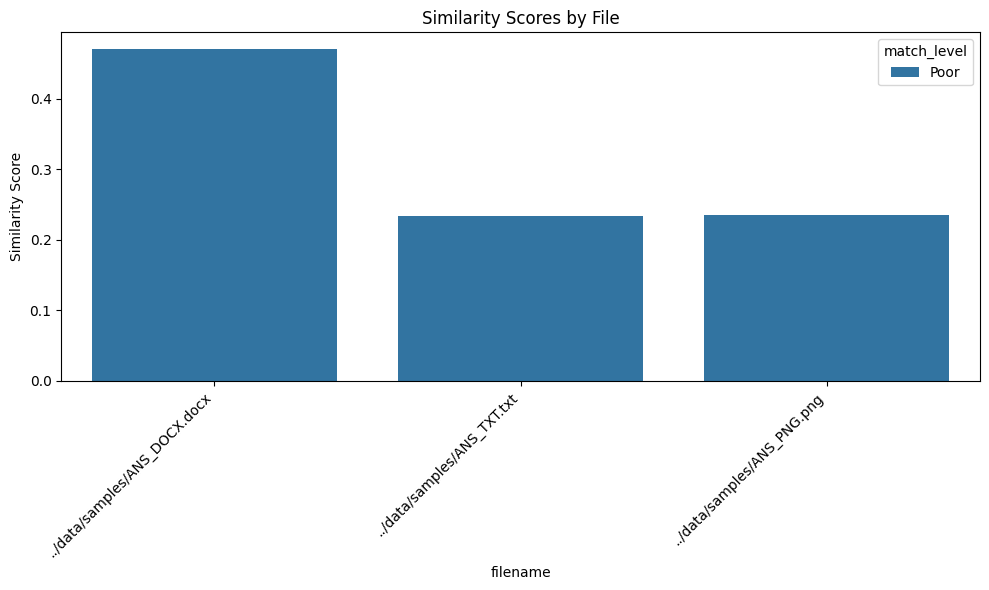

In [7]:
plot_similarity_bar_chart(df)

Test the pie chart

2026-08-03 00:11:07 | INFO     | src.visualization.charts | Saved pie chart to data\outputs\match_level_pie.png


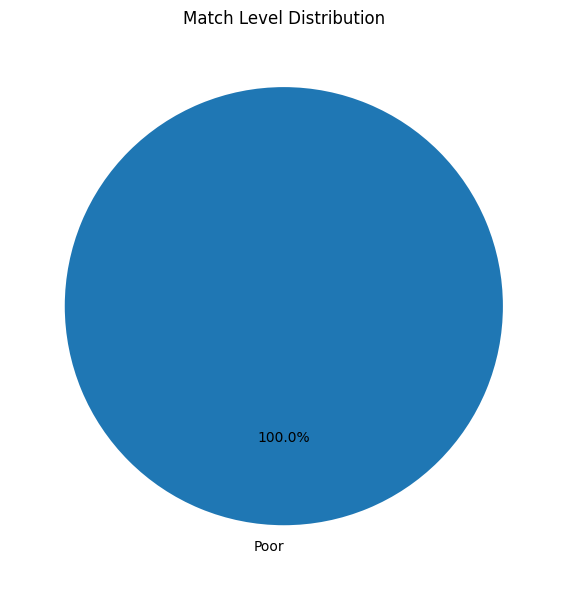

In [8]:
plot_match_level_pie(df)

Test the word cloud (using preprocessed text)

2026-08-03 00:11:09 | INFO     | src.preprocessing.preprocessor | Loading spaCy model: en_core_web_sm
2026-08-03 00:11:34 | INFO     | src.visualization.wordcloud_gen | Saved word cloud to data\outputs\master_answer_key_word_cloud.png


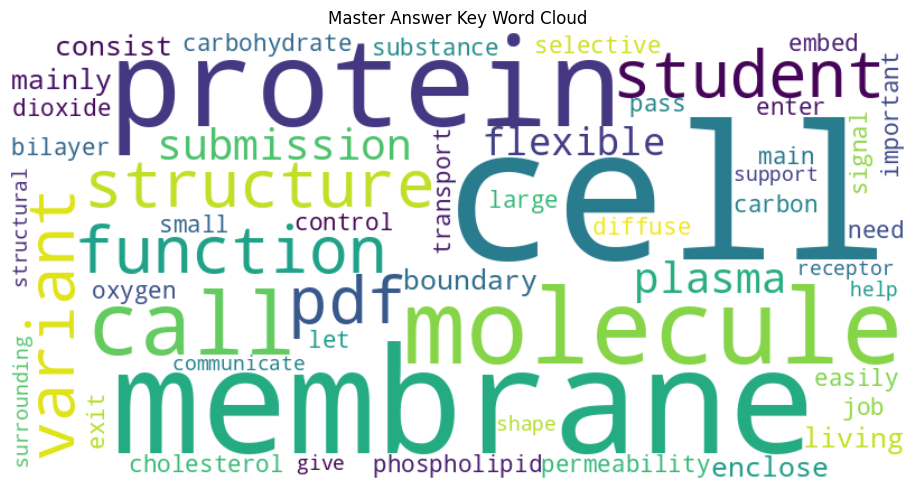

In [9]:
preprocessor = TextPreprocessor()
cleaned_master = preprocessor.preprocess_to_string(master_raw)

generate_wordcloud(cleaned_master, title="Master Answer Key Word Cloud")

Test CSV export

In [10]:
export_report_csv(df)

2026-08-03 00:11:38 | INFO     | src.visualization.report_generator | Exported report to data\outputs\similarity_report.csv
